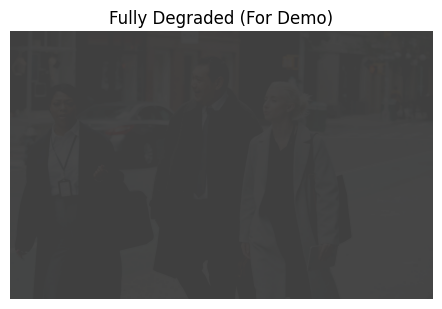

Time taken:  2.88774037361145
Number of faces:  0


In [10]:
import cv2
from model_haar import detect_face
from model_yunet import detect_face_yunet
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent

image_path = ROOT / "assets" / "test3.jpg"

expected_faces = 2

def create_fully_degraded_image(image_path):
    
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Image not found!")
        return None

    
    degraded = img.astype(np.float32)

    
    degraded = (degraded - 30) / 1.2
    degraded = np.clip(degraded, 0, 255)

    
    degraded = (degraded / 255.0) * 0.05 + 0.5
    degraded = (degraded * 255).astype(np.uint8)


    inv_gamma = 1.0 / 2
    table = np.array([((i / 255.0) ** (1.0 / inv_gamma)) * 255 for i in np.arange(0, 256)]).astype("uint8")
    degraded = cv2.LUT(degraded, table)


    degraded = cv2.GaussianBlur(degraded, (15, 15), 0)

    return degraded

bad_image = create_fully_degraded_image(image_path)

if bad_image is not None:
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(bad_image, cv2.COLOR_BGR2RGB))
    plt.title("Fully Degraded (For Demo)")
    plt.axis('off')
    
    plt.show()
    
img = cv2.imread(image_path)
result, n, t = detect_face_yunet(bad_image)
print("Time taken: ", t)
print("Number of faces: ", n)